<a href="https://colab.research.google.com/github/AAwaisYaseen/computer-vision-logistics/blob/main/COMP6011_pidnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
# For S
# https://drive.google.com/file/d/1wnMVQOmTEkSm8dB2A9TsSHG-yCgpGN0b/view?usp=drive_link

# For M
# https://drive.google.com/file/d/1nCBp6OC8uXYdzDsSmhdw5a5zUF5Mce-6/view?usp=drive_link

# https://github.com/xujiacong/pidnet?tab=readme-ov-file

# weight link for PIDNET cityscapes
# https://drive.google.com/drive/folders/0BySIOtxxULinfld0LTcxYndTbFpWNjVpWm9nREU1T3hJUW5IS2otOUJDMmtnZERuODFPVU0?resourcekey=0-nauDQNE1efkunvcg89ZlDA

In [17]:
!pip install torch torchvision --quiet
!pip install numpy pillow tqdm matplotlib --quiet

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
import os

ZIP_PATH = '/content/drive/MyDrive/AAIRT1/sydneyscapes.zip'
EXTRACT_PATH = '/content/sydneyscapes'

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)
print('Done!')

DATASET_PATH = '/content/sydneyscapes/sydneyscapes'
print('DATASET_PATH:', DATASET_PATH)

Mounted at /content/drive
Done!
DATASET_PATH: /content/sydneyscapes/sydneyscapes


In [3]:
import os
import time
import numpy as np
from PIL import Image
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [4]:
with open(os.path.join(DATASET_PATH, 'val.txt'), 'r') as f:
    val_files = [line.strip() for line in f.readlines()]

print(f'Total validation images: {len(val_files)}')

Total validation images: 152


In [5]:
def compute_miou_direct(preds, labels, num_classes=19, ignore_index=255):
    iou_list = []
    for cls in range(num_classes):
        pred_mask = preds == cls
        label_mask = labels == cls
        valid_mask = labels != ignore_index
        intersection = (pred_mask & label_mask & valid_mask).sum()
        union = ((pred_mask | label_mask) & valid_mask).sum()
        if union == 0:
            continue
        iou_list.append(intersection / union)
    return np.mean(iou_list) if iou_list else 0.0

print('mIoU function ready.')

mIoU function ready.


In [6]:
transform = transforms.Compose([
    transforms.Resize((512, 1024)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
print('Transform ready.')

Transform ready.


In [7]:
!git clone https://github.com/XuJiacong/PIDNet.git
%cd /content/PIDNet
print('Done:', os.listdir('/content/PIDNet'))

Cloning into 'PIDNet'...
remote: Enumerating objects: 398, done.
remote: Counting objects: 100% (201/201), done.
remote: Compressing objects: 100% (73/73), done.
remote: Total 398 (delta 139), reused 128 (delta 128), pack-reused 197 (from 2)
Receiving objects: 100% (398/398), 212.80 MiB | 24.17 MiB/s, done.
Resolving deltas: 100% (192/192), done.
/content/PIDNet
Done: ['figs', 'datasets', 'tools', 'utils', 'data', 'configs', '.git', 'pretrained_models', 'LICENSE', 'models', 'samples', 'README.md']


In [8]:
import gdown
import os

os.makedirs('/content/PIDNet/pretrained_models/cityscapes', exist_ok=True)

print('Downloading PIDNet-S...')
gdown.download(
    'https://drive.google.com/file/d/1wnMVQOmTEkSm8dB2A9TsSHG-yCgpGN0b/view?usp=drive_link',
    '/content/PIDNet/pretrained_models/cityscapes/PIDNet_S_Cityscapes_val.pt',
    fuzzy=True
)

print('Downloading PIDNet-M...')
gdown.download(
    'https://drive.google.com/file/d/1nCBp6OC8uXYdzDsSmhdw5a5zUF5Mce-6/view?usp=drive_link',
    '/content/PIDNet/pretrained_models/cityscapes/PIDNet_M_Cityscapes_val.pt',
    fuzzy=True
)

# Verify
print('PIDNet-S exists:', os.path.exists('/content/PIDNet/pretrained_models/cityscapes/PIDNet_S_Cityscapes_val.pt'))
print('PIDNet-M exists:', os.path.exists('/content/PIDNet/pretrained_models/cityscapes/PIDNet_M_Cityscapes_val.pt'))

Downloading...
From (original): https://drive.google.com/uc?id=1wnMVQOmTEkSm8dB2A9TsSHG-yCgpGN0b
From (redirected): https://drive.google.com/uc?id=1wnMVQOmTEkSm8dB2A9TsSHG-yCgpGN0b&confirm=t&uuid=90b17fc9-e4e7-41ba-a29a-da8030b28812
To: /content/PIDNet/pretrained_models/cityscapes/PIDNet_S_Cityscapes_val.pt
100%|██████████| 31.1M/31.1M [00:00<00:00, 70.3MB/s]


Downloading...
From (original): https://drive.google.com/uc?id=1nCBp6OC8uXYdzDsSmhdw5a5zUF5Mce-6
From (redirected): https://drive.google.com/uc?id=1nCBp6OC8uXYdzDsSmhdw5a5zUF5Mce-6&confirm=t&uuid=5f947b3f-10fb-4d33-a8f1-d4eee60c1834
To: /content/PIDNet/pretrained_models/cityscapes/PIDNet_M_Cityscapes_val.pt
100%|██████████| 139M/139M [00:02<00:00, 66.3MB/s]

PIDNet-S exists: True
PIDNet-M exists: True


In [14]:
print('Loading PIDNet-S...')
pidnet_s = get_pred_model('pidnet-s', 19)
checkpoint_s = torch.load(
    '/content/PIDNet/pretrained_models/cityscapes/PIDNet_S_Cityscapes_val.pt',
    map_location=device,
    weights_only=False
)
new_state_s = {k.replace('model.', ''): v for k, v in checkpoint_s.items()}
pidnet_s.load_state_dict(new_state_s, strict=False)
pidnet_s = pidnet_s.to(device)
pidnet_s.eval()
print('PIDNet-S loaded successfully.')

print('Loading PIDNet-M...')
pidnet_m = get_pred_model('pidnet-m', 19)
checkpoint_m = torch.load(
    '/content/PIDNet/pretrained_models/cityscapes/PIDNet_M_Cityscapes_val.pt',
    map_location=device,
    weights_only=False
)
new_state_m = {k.replace('model.', ''): v for k, v in checkpoint_m.items()}
pidnet_m.load_state_dict(new_state_m, strict=False)
pidnet_m = pidnet_m.to(device)
pidnet_m.eval()
print('PIDNet-M loaded successfully.')

Loading PIDNet-S...
PIDNet-S loaded successfully.
Loading PIDNet-M...
PIDNet-M loaded successfully.


In [15]:
pidnet_s_ious = []
pidnet_s_times = []
skipped = 0

print('Running PIDNet-S on SydneyScapes validation set...')

for file_id in tqdm(val_files):
    subset = file_id.split('/')[0]
    base_name = file_id.split('/')[1]

    img_path = os.path.join(DATASET_PATH, 'leftImg8bit/val', subset,
                            base_name + '_leftImg8bit.png')
    label_path = os.path.join(DATASET_PATH, 'gtFine/val', subset,
                              base_name + '_gtFine_labelTrainIds.png')

    if not os.path.exists(img_path) or not os.path.exists(label_path):
        skipped += 1
        continue

    img = Image.open(img_path).convert('RGB')
    label_array = np.array(Image.open(label_path))

    input_tensor = transform(img).unsqueeze(0).to(device)

    start = time.time()
    with torch.no_grad():
        output = pidnet_s(input_tensor)
    elapsed = time.time() - start

    pred = output.argmax(1).squeeze().cpu().numpy()
    pred_resized = np.array(
        Image.fromarray(pred.astype(np.uint8)).resize(
            (label_array.shape[1], label_array.shape[0]),
            Image.NEAREST
        )
    )

    iou = compute_miou_direct(pred_resized, label_array)
    pidnet_s_ious.append(iou)
    pidnet_s_times.append(elapsed)

pidnet_s_miou = np.mean(pidnet_s_ious) * 100
pidnet_s_fps = 1.0 / np.mean(pidnet_s_times)

print(f'\nPIDNet-S Results:')
print(f'Images evaluated: {len(pidnet_s_ious)} | Skipped: {skipped}')
print(f'mIoU: {pidnet_s_miou:.2f}%')
print(f'FPS: {pidnet_s_fps:.1f}')

Running PIDNet-S on SydneyScapes validation set...


100%|██████████| 152/152 [02:34<00:00,  1.02s/it]


PIDNet-S Results:
Images evaluated: 152 | Skipped: 0
mIoU: 31.21%
FPS: 1.4


In [18]:
pidnet_m_ious = []
pidnet_m_times = []
skipped = 0

print('Running PIDNet-M on SydneyScapes validation set...')

for file_id in tqdm(val_files):
    subset = file_id.split('/')[0]
    base_name = file_id.split('/')[1]

    img_path = os.path.join(DATASET_PATH, 'leftImg8bit/val', subset,
                            base_name + '_leftImg8bit.png')
    label_path = os.path.join(DATASET_PATH, 'gtFine/val', subset,
                              base_name + '_gtFine_labelTrainIds.png')

    if not os.path.exists(img_path) or not os.path.exists(label_path):
        skipped += 1
        continue

    img = Image.open(img_path).convert('RGB')
    label_array = np.array(Image.open(label_path))

    input_tensor = transform(img).unsqueeze(0).to(device)

    start = time.time()
    with torch.no_grad():
        output = pidnet_m(input_tensor)
    elapsed = time.time() - start

    pred = output.argmax(1).squeeze().cpu().numpy()
    pred_resized = np.array(
        Image.fromarray(pred.astype(np.uint8)).resize(
            (label_array.shape[1], label_array.shape[0]),
            Image.NEAREST
        )
    )

    iou = compute_miou_direct(pred_resized, label_array)
    pidnet_m_ious.append(iou)
    pidnet_m_times.append(elapsed)

pidnet_m_miou = np.mean(pidnet_m_ious) * 100
pidnet_m_fps = 1.0 / np.mean(pidnet_m_times)

print(f'\nPIDNet-M Results:')
print(f'Images evaluated: {len(pidnet_m_ious)} | Skipped: {skipped}')
print(f'mIoU: {pidnet_m_miou:.2f}%')
print(f'FPS: {pidnet_m_fps:.1f}')

Running PIDNet-M on SydneyScapes validation set...


100%|██████████| 152/152 [06:01<00:00,  2.38s/it]


PIDNet-M Results:
Images evaluated: 152 | Skipped: 0
mIoU: 29.07%
FPS: 0.5


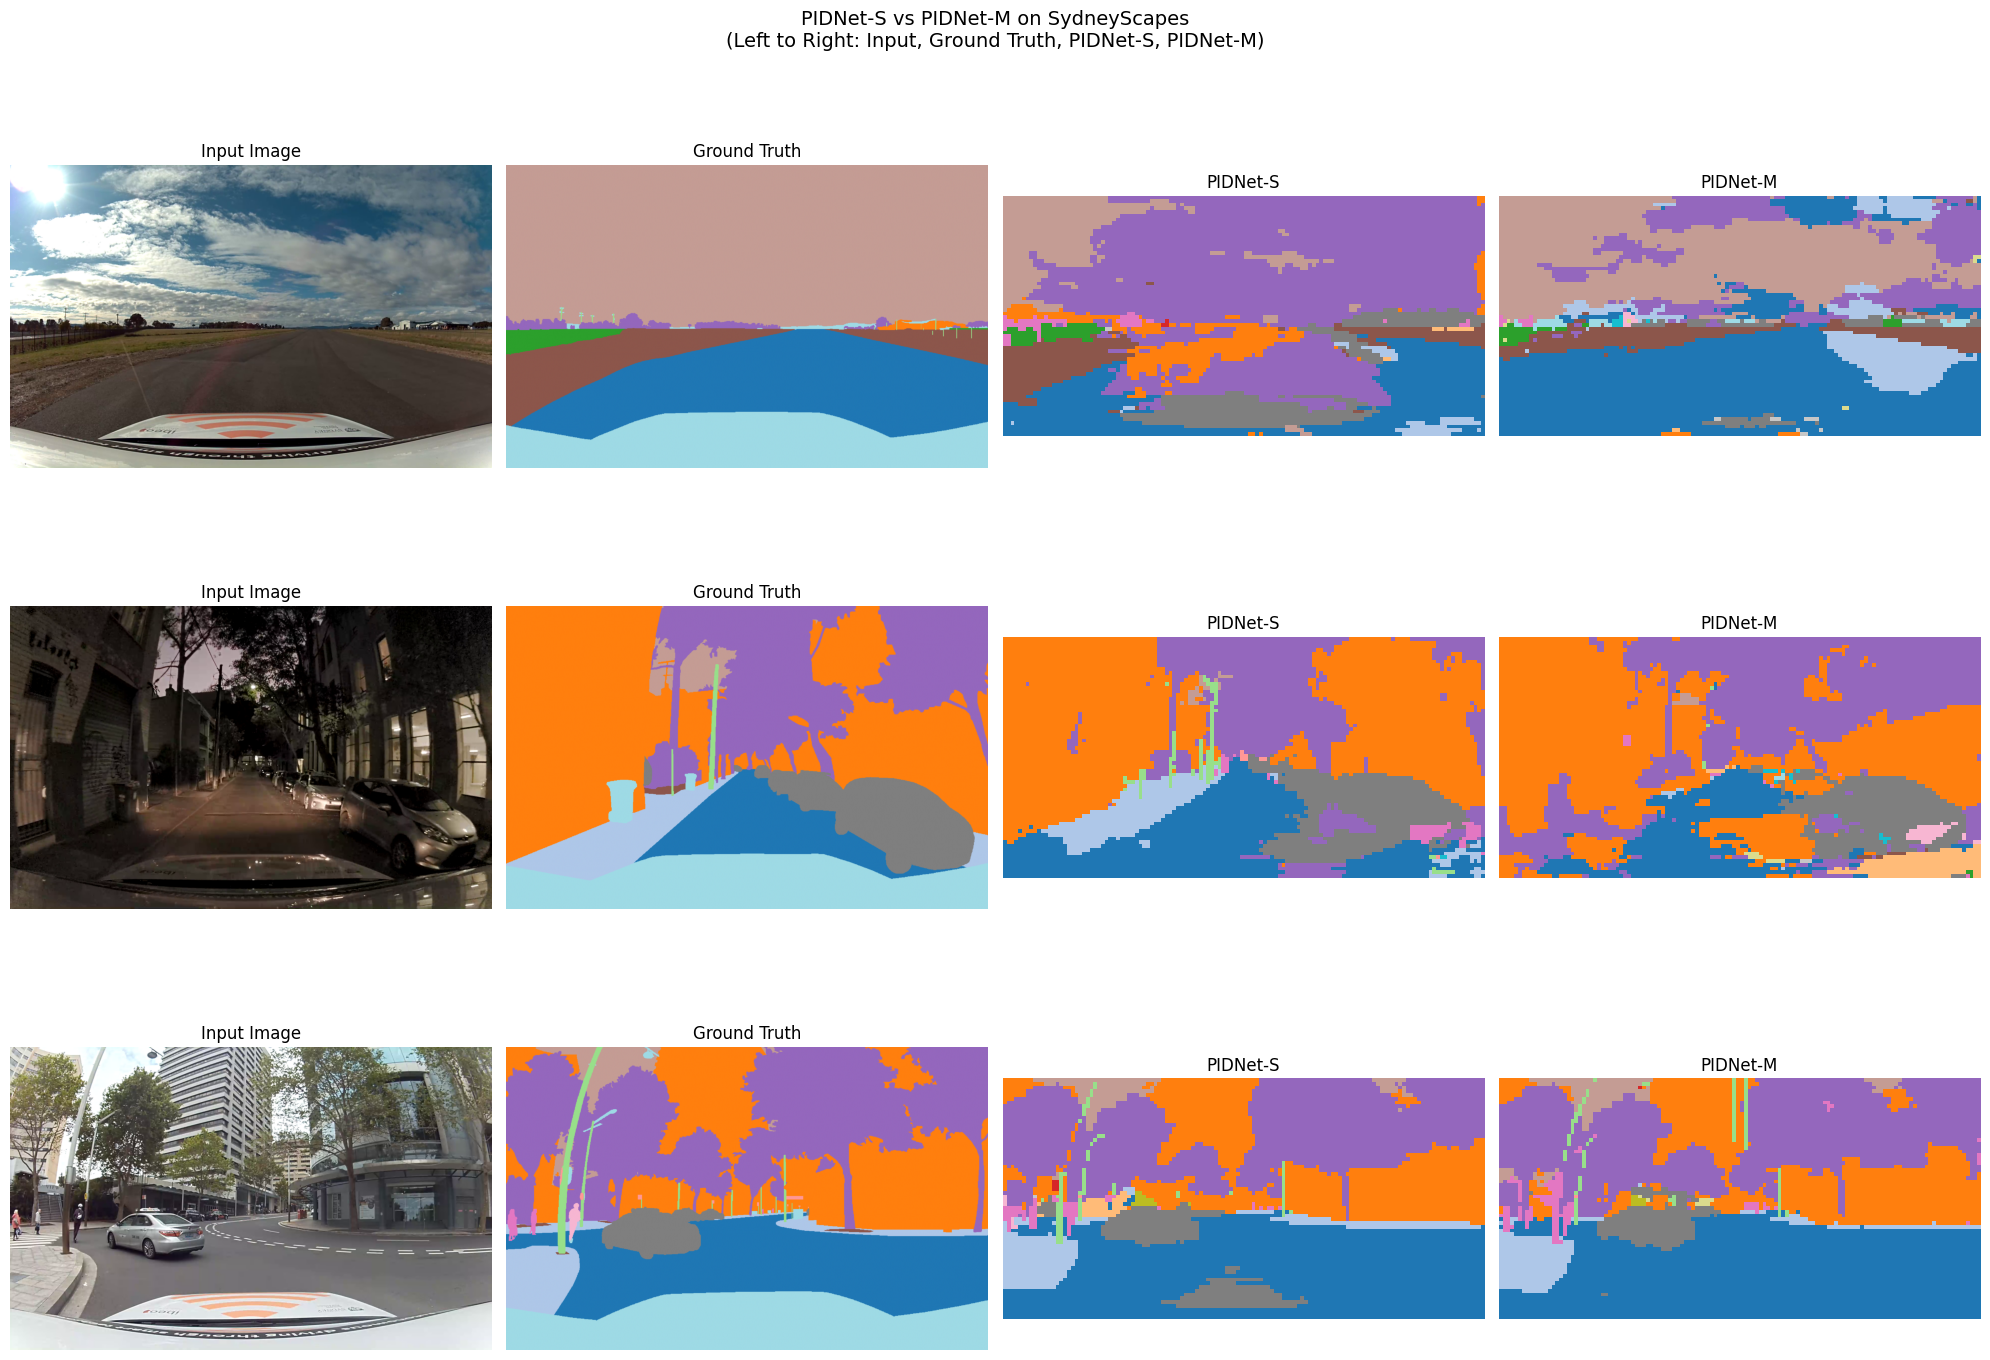

Saved to /content/pidnet_comparison.png


In [19]:
import matplotlib.pyplot as plt

samples = {
    'NSWday': 'NSWday/NSWday_000009_345013',
    'NSWnight': 'NSWnight/NSWnight_000285_268036',
    'NSWpeople': 'NSWpeople/NSWpeople_000048_974884'
}

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
row_labels = ['NSWday', 'NSWnight', 'NSWpeople']

for row, (subset_name, file_id) in enumerate(samples.items()):
    subset = file_id.split('/')[0]
    base_name = file_id.split('/')[1]

    img_path = os.path.join(DATASET_PATH, 'leftImg8bit/val',
                            subset, base_name + '_leftImg8bit.png')
    label_path = os.path.join(DATASET_PATH, 'gtFine/val',
                              subset, base_name + '_gtFine_labelTrainIds.png')

    img = Image.open(img_path).convert('RGB')
    label_array = np.array(Image.open(label_path))
    input_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        pred_s = pidnet_s(input_tensor).argmax(1).squeeze().cpu().numpy()
        pred_m = pidnet_m(input_tensor).argmax(1).squeeze().cpu().numpy()

    axes[row, 0].imshow(img)
    axes[row, 0].set_title('Input Image')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(label_array, cmap='tab20', vmin=0, vmax=18)
    axes[row, 1].set_title('Ground Truth')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(pred_s, cmap='tab20', vmin=0, vmax=18)
    axes[row, 2].set_title(f'PIDNet-S')
    axes[row, 2].axis('off')

    axes[row, 3].imshow(pred_m, cmap='tab20', vmin=0, vmax=18)
    axes[row, 3].set_title(f'PIDNet-M')
    axes[row, 3].axis('off')

    axes[row, 0].set_ylabel(row_labels[row], fontsize=12)

plt.suptitle('PIDNet-S vs PIDNet-M on SydneyScapes\n(Left to Right: Input, Ground Truth, PIDNet-S, PIDNet-M)',
             fontsize=14)
plt.tight_layout()
plt.savefig('/content/pidnet_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to /content/pidnet_comparison.png')

In [20]:
import shutil
shutil.copy('/content/pidnet_comparison.png',
            '/content/drive/MyDrive/AAIRT1/pidnet_comparison.png')
print('Saved to Drive.')

Saved to Drive.


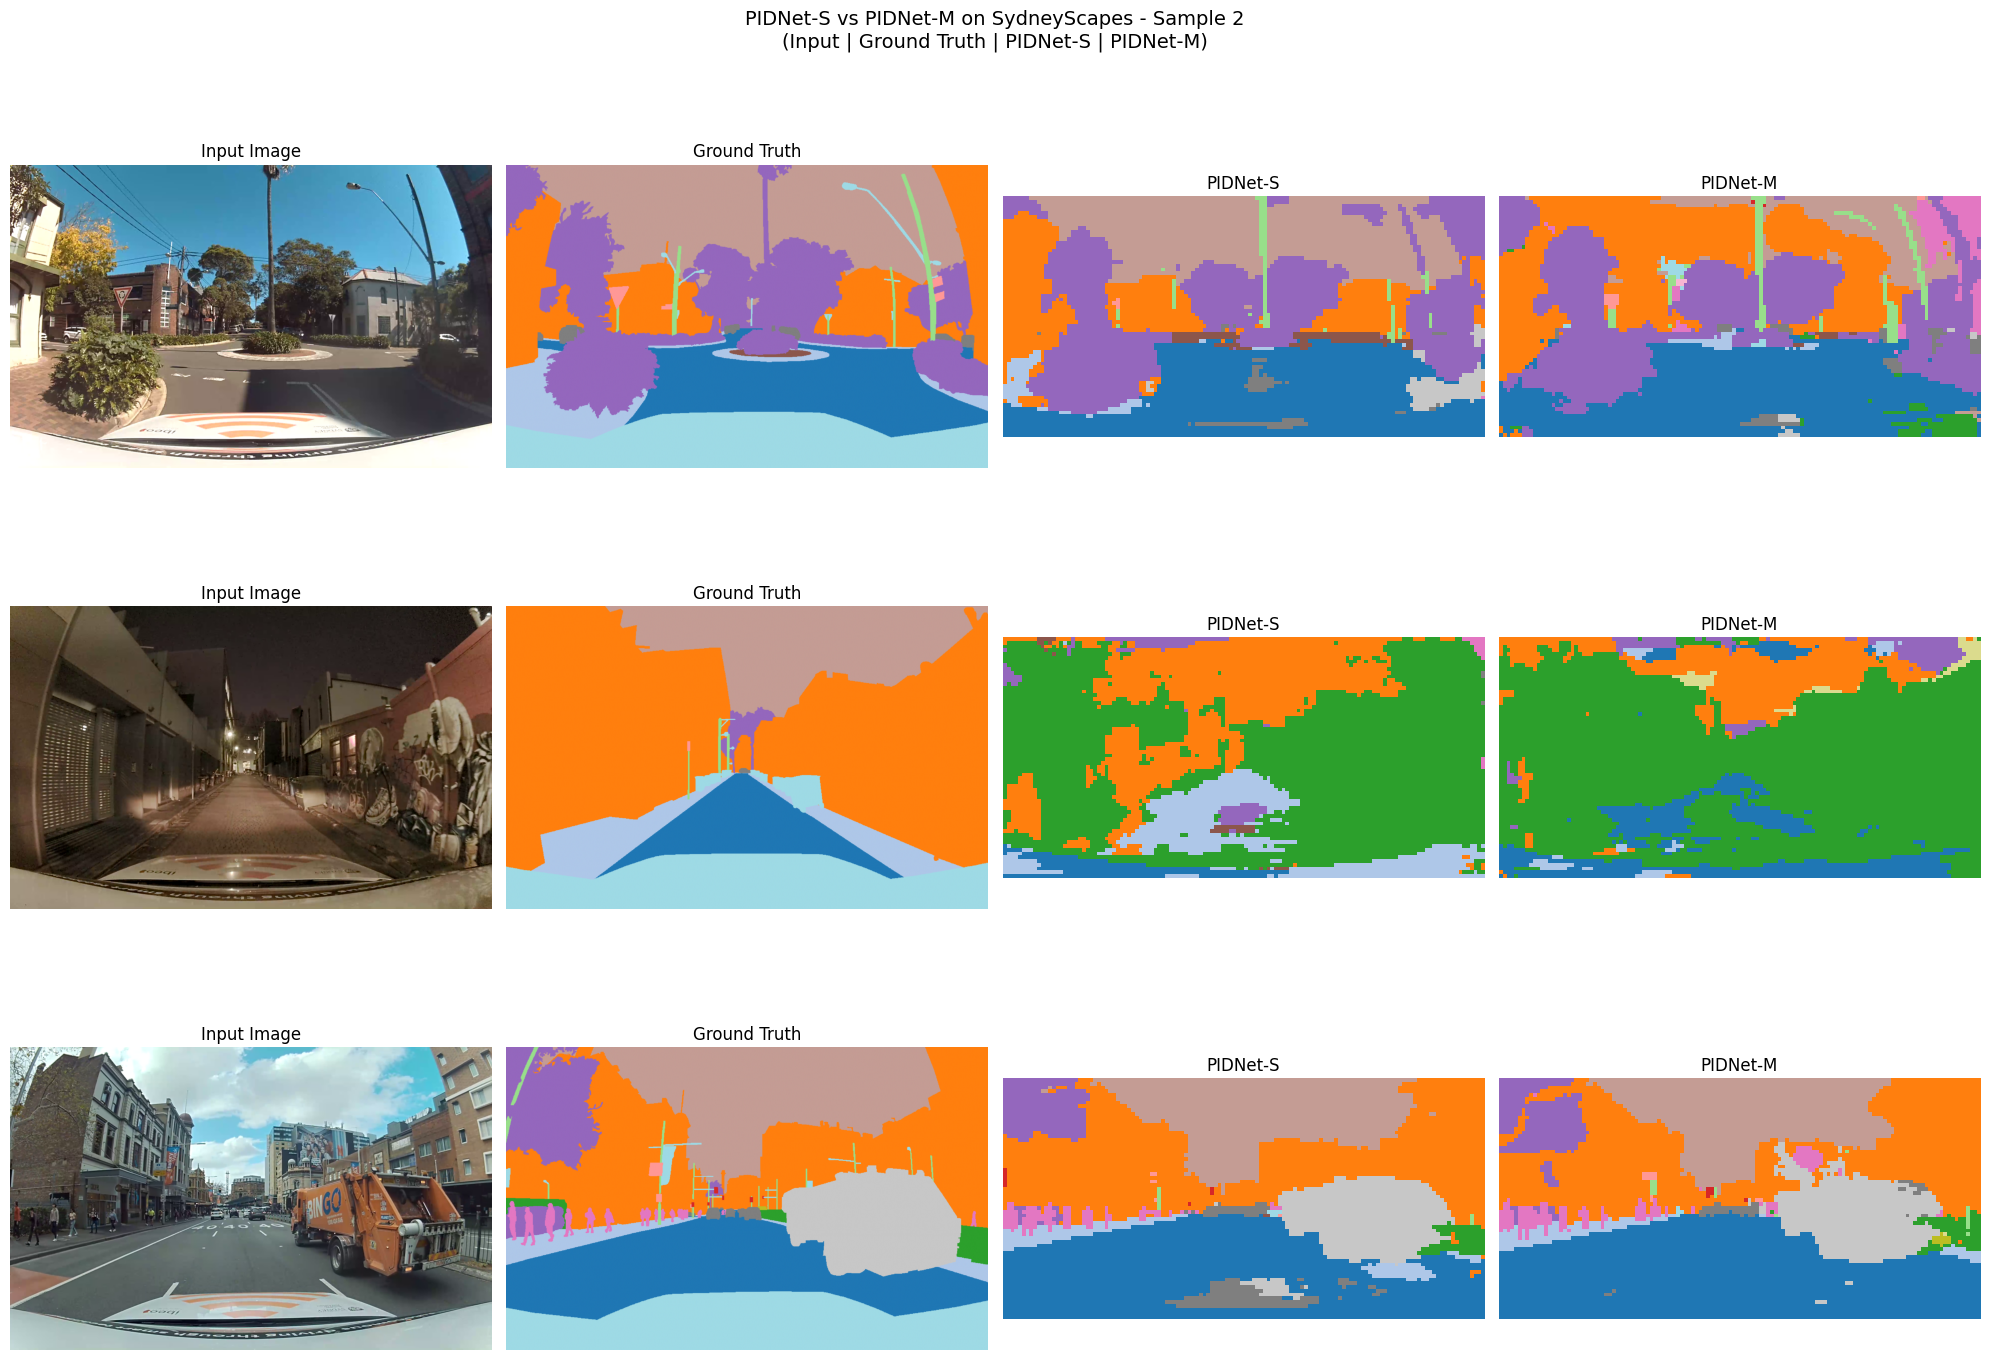

Done


In [21]:
samples = {
    'NSWday - Highway': 'NSWday/NSWday_000528_175812',
    'NSWnight - Street': 'NSWnight/NSWnight_003357_267988',
    'NSWpeople - Crowd': 'NSWpeople/NSWpeople_025389_556881'
}

fig, axes = plt.subplots(3, 4, figsize=(20, 15))

for row, (scene_name, file_id) in enumerate(samples.items()):
    subset = file_id.split('/')[0]
    base_name = file_id.split('/')[1]

    img_path = os.path.join(DATASET_PATH, 'leftImg8bit/val',
                            subset, base_name + '_leftImg8bit.png')
    label_path = os.path.join(DATASET_PATH, 'gtFine/val',
                              subset, base_name + '_gtFine_labelTrainIds.png')

    img = Image.open(img_path).convert('RGB')
    label_array = np.array(Image.open(label_path))
    input_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        pred_s = pidnet_s(input_tensor).argmax(1).squeeze().cpu().numpy()
        pred_m = pidnet_m(input_tensor).argmax(1).squeeze().cpu().numpy()

    axes[row, 0].imshow(img)
    axes[row, 0].set_title('Input Image')
    axes[row, 0].axis('off')
    axes[row, 0].set_ylabel(scene_name, fontsize=10)

    axes[row, 1].imshow(label_array, cmap='tab20', vmin=0, vmax=18)
    axes[row, 1].set_title('Ground Truth')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(pred_s, cmap='tab20', vmin=0, vmax=18)
    axes[row, 2].set_title('PIDNet-S')
    axes[row, 2].axis('off')

    axes[row, 3].imshow(pred_m, cmap='tab20', vmin=0, vmax=18)
    axes[row, 3].set_title('PIDNet-M')
    axes[row, 3].axis('off')

plt.suptitle('PIDNet S vs PIDNet M on SydneyScapes - Sample 2\n(Input | Ground Truth | PIDNet-S | PIDNet-M)',
             fontsize=14)
plt.tight_layout()
plt.savefig('/content/pidnet_comparison_2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Done')

In [22]:
import shutil
shutil.copy('/content/pidnet_comparison_2.png',
            '/content/drive/MyDrive/AAIRT1/pidnet_comparison_2.png')
print('Saved to Drive.')

Saved to Drive.
